In [94]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import requests
import time
from scipy import stats as st
import os

In [95]:
visits_path = os.path.join(os.getcwd(), 'visits_log_us.csv')
visits = pd.read_csv(visits_path)

orders_path = os.path.join(os.getcwd(), 'orders_log_us.csv')
orders = pd.read_csv(orders_path)

costs_path = os.path.join(os.getcwd(), 'costs_us.csv')
costs = pd.read_csv(costs_path)

## Explorando cada dataset

In [96]:
print('VISITS:')
print()
print(visits.info())
print(visits.head())

VISITS:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB
None
    Device               End Ts  Source Id             Start Ts  \
0    touch  2017-12-20 17:38:00          4  2017-12-20 17:20:00   
1  desktop  2018-02-19 17:21:00          2  2018-02-19 16:53:00   
2    touch  2017-07-01 01:54:00          5  2017-07-01 01:54:00   
3  desktop  2018-05-20 11:23:00          9  2018-05-20 10:59:00   
4  desktop  2017-12-27 14:06:00          3  2017-12-27 14:06:00   

                    Uid  
0  16879256277535980062  
1    104060357244891740  
2   7459035603376831527  
3  16174680259334210214  
4

In [97]:
print('ORDERS:')
print()
print(orders.info())
print(orders.head())

ORDERS:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB
None
                Buy Ts  Revenue                   Uid
0  2017-06-01 00:10:00    17.00  10329302124590727494
1  2017-06-01 00:25:00     0.55  11627257723692907447
2  2017-06-01 00:27:00     0.37  17903680561304213844
3  2017-06-01 00:29:00     0.55  16109239769442553005
4  2017-06-01 07:58:00     0.37  14200605875248379450


In [98]:
print('COSTS:')
print()
print(costs.info())
print(costs.head())

COSTS:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  2542 non-null   int64  
 1   dt         2542 non-null   object 
 2   costs      2542 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 59.7+ KB
None
   source_id          dt  costs
0          1  2017-06-01  75.20
1          1  2017-06-02  62.25
2          1  2017-06-03  36.53
3          1  2017-06-04  55.00
4          1  2017-06-05  57.08


## Otimizando datasets

In [99]:
visits['End Ts'] = pd.to_datetime(visits['End Ts'])
visits['Start Ts'] = pd.to_datetime(visits['Start Ts'])

In [100]:
orders['Buy Ts'] = pd.to_datetime(orders['Buy Ts'])

In [101]:
costs['dt'] = pd.to_datetime(costs['dt'])

#### Otimizações realizadas:

**VISITS:**
- End Ts e Start Ts estavam como object e foram convertidas em datetime

**ORDERS:**
- Buy Ts estava como object e foi convertida e datetime

**COSTS:**
- dt estava como object e foi convertida e datetime

## Relatórios e métricas

### Quantidade de usuários

In [102]:
# Criação de coluna de data e verificação de usuários por dia
visits['date'] = visits['Start Ts'].dt.date
daily_users = visits.groupby('date')['Uid'].nunique()
print('Daily users:')
print()
print(daily_users.head(20))
print('\nMenor número de usuários registrados em um dia:')
print(daily_users.min())
print('\nMaior número de usuários registrados em um dia:')
print(daily_users.max())

Daily users:

date
2017-06-01    605
2017-06-02    608
2017-06-03    445
2017-06-04    476
2017-06-05    820
2017-06-06    797
2017-06-07    699
2017-06-08    868
2017-06-09    695
2017-06-10    350
2017-06-11    292
2017-06-12    335
2017-06-13    502
2017-06-14    499
2017-06-15    575
2017-06-16    481
2017-06-17    328
2017-06-18    285
2017-06-19    482
2017-06-20    458
Name: Uid, dtype: int64

Menor número de usuários registrados em um dia:
1

Maior número de usuários registrados em um dia:
3319


In [103]:
# Criação de coluna de semana e contagem de usuários
visits['week_period'] = visits['Start Ts'].dt.to_period('W')
weekly_users = visits.groupby('week_period')['Uid'].nunique()
print('Weekly users:')
print()
print(weekly_users)

Weekly users:

week_period
2017-05-29/2017-06-04     2021
2017-06-05/2017-06-11     4129
2017-06-12/2017-06-18     2812
2017-06-19/2017-06-25     2878
2017-06-26/2017-07-02     3064
2017-07-03/2017-07-09     3294
2017-07-10/2017-07-16     4355
2017-07-17/2017-07-23     3841
2017-07-24/2017-07-30     2655
2017-07-31/2017-08-06     2364
2017-08-07/2017-08-13     2444
2017-08-14/2017-08-20     2746
2017-08-21/2017-08-27     3116
2017-08-28/2017-09-03     3694
2017-09-04/2017-09-10     4412
2017-09-11/2017-09-17     4319
2017-09-18/2017-09-24     4874
2017-09-25/2017-10-01     6241
2017-10-02/2017-10-08     7612
2017-10-09/2017-10-15     7074
2017-10-16/2017-10-22     7148
2017-10-23/2017-10-29     7401
2017-10-30/2017-11-05     7480
2017-11-06/2017-11-12     7179
2017-11-13/2017-11-19     8117
2017-11-20/2017-11-26    10586
2017-11-27/2017-12-03     8166
2017-12-04/2017-12-10     8407
2017-12-11/2017-12-17     8214
2017-12-18/2017-12-24     7172
2017-12-25/2017-12-31     7774
2018-01-01/2

In [104]:
# Criação de coluna de mês e contagem de usuários
visits['month_period'] = visits['Start Ts'].dt.to_period('M')
monthly_users = visits.groupby('month_period')['Uid'].nunique()
print('Monthly users:')
print()
print(monthly_users)

Monthly users:

month_period
2017-06    13259
2017-07    14183
2017-08    11631
2017-09    18975
2017-10    29692
2017-11    32797
2017-12    31557
2018-01    28716
2018-02    28749
2018-03    27473
2018-04    21008
2018-05    20701
Freq: M, Name: Uid, dtype: int64


### Interpretações:
#### Tendências observadas:

Inicialmente é possível observar crescimento de ~2000 usuários semanais no início do período de junho/2017 (com 13.529 usuários mensais) para pico de ~10500 após 5 meses, em novembro/2017 (com 32.797 usuários mensais). Em seguida tivemos estabilização em ~7000-8000 usuários com posterior declínio gradual.

### Métricas sobre as sessões

In [105]:
# Visualizando a quantidade total de sessões diárias
daily_sessions = visits.groupby('date').size()
print('Daily sessions:')
print()
print(daily_sessions.head(20))

Daily sessions:

date
2017-06-01    664
2017-06-02    658
2017-06-03    477
2017-06-04    510
2017-06-05    893
2017-06-06    875
2017-06-07    788
2017-06-08    939
2017-06-09    755
2017-06-10    375
2017-06-11    306
2017-06-12    355
2017-06-13    536
2017-06-14    547
2017-06-15    609
2017-06-16    524
2017-06-17    337
2017-06-18    306
2017-06-19    518
2017-06-20    498
dtype: int64


In [106]:
# Visualizando a duração das sessões
sessions_length = visits['End Ts'] - visits['Start Ts']
print('Duração das sessões:')
print()
print(sessions_length)

Duração das sessões:

0        0 days 00:18:00
1        0 days 00:28:00
2        0 days 00:00:00
3        0 days 00:24:00
4        0 days 00:00:00
               ...      
359395   0 days 00:00:19
359396   0 days 00:00:19
359397   0 days 00:00:19
359398   0 days 00:00:19
359399   0 days 00:00:19
Length: 359400, dtype: timedelta64[ns]


Interessante observar que não possuímos sessões entre 0 e 1 minuto. Isso sugere que o sistema de tracking pode estar arredondando os timestamps ou registrando apenas em intervalos de minutos completos.

In [107]:
# Contando quantas sessões cada usuário fez
user_session_count = visits.groupby('Uid').size()
print('Distribuição de sessões por usuário:')
print()
print(user_session_count.describe())

Distribuição de sessões por usuário:

count    228169.000000
mean          1.575148
std           4.646800
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max         893.000000
dtype: float64


In [108]:
# Filtrando usuários que fizeram mais de 1 sessão
returning_users = user_session_count[user_session_count > 1].index

# Calculando o intervalo entre visitas para cada usuário que retornou 
user_visit_intervals = []

for user in returning_users:
    user_visits = visits[visits['Uid'] == user]['Start Ts'].sort_values()
    intervals = user_visits.diff().dropna()  # Diferença entre visitas consecutivas
    user_visit_intervals.extend(intervals)

# Convertendo para DataFrame para análise
intervals_df = pd.Series(user_visit_intervals)
print('Intervalos entre visitas (em dias):')
print()
print((intervals_df.dt.total_seconds() / (24 * 3600)).describe())

Intervalos entre visitas (em dias):

count    131231.000000
mean         28.110194
std          49.728746
min           0.000000
25%           0.678472
50%           4.905556
75%          31.963542
max         362.540278
dtype: float64


### Conclusão sobre as sessões

Observamos que os usuários da Y.Afisha possuem um padrão de retorno mensal (a cada 28 dias em média)

## Análise de vendas

In [109]:
# Descobrindo o tempo de conversão - período entre a primeira visita e a primeira compra

# Primeira visita de cada usuário
first_visits_dates = visits.groupby('Uid')['Start Ts'].min()

# Primeira compra de cada usuário
first_orders_dates = orders.groupby('Uid')['Buy Ts'].min()

# Encontrando usuários que visitaram e compraram
common_users = first_visits_dates.index.intersection(first_orders_dates.index)

# Calculando tempo de conversão apenas para esses usuários
conversion_time = first_orders_dates[common_users] - first_visits_dates[common_users]

print('Tempo de conversão:')
print()
print((conversion_time.dt.total_seconds() / (24 * 3600)).describe())

Tempo de conversão:

count    36523.000000
mean        16.902900
std         47.072760
min          0.000000
25%          0.002778
50%          0.011111
75%          2.011806
max        363.294444
dtype: float64


### Conclusões sobre as conversões

Tivemos conversão de um total de 36.523 usuários. Onde podemos observar que a média de conversão é de 16.9 dias, ou seja, um usuário leva, em média, um pouco mais de duas semanas entre a primeira visita e a primeira compra.

Outras métricas relevantes são que:

- 75% dos usuários compram em até 2 dias

- metade dos usuários compram em minutos (0.011 dias ≈ 16 minutos)

- o pior tempo de conversão foi de 363 dias

- isso nos mostra porque a média está alta, como alguns usuários demoram muito para comprar, isso acaba elevando a média

In [110]:
# Descobrindo a quantidade de pedidos por usuário
orders_per_user = orders.groupby('Uid')['Buy Ts'].count()
print('Quantidade de pedidos por usuário:')
print()
print(orders_per_user.describe())

Quantidade de pedidos por usuário:

count    36523.000000
mean         1.380363
std          3.454461
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        239.000000
Name: Buy Ts, dtype: float64


In [111]:
# Quantidade de usuários que fazem exatamente um pedido
orders_per_user.value_counts().head(10)

Buy Ts
1     30231
2      4395
3      1086
4       375
5       147
6        79
7        41
8        24
10       15
12       10
Name: count, dtype: int64

In [112]:
# Calculando % de one-time buyers
one_time_buyers = 30231
total_buyers = 36523

percentage_one_time = (one_time_buyers / total_buyers) * 100
print(f'One-time buyers: {percentage_one_time:.1f}%')

# Calculando % de repeat buyers (compraram 2+ vezes)
repeat_buyers = total_buyers - one_time_buyers
percentage_repeat = (repeat_buyers / total_buyers) * 100
print(f'\nRepeat buyers: {percentage_repeat:.1f}%')

One-time buyers: 82.8%

Repeat buyers: 17.2%


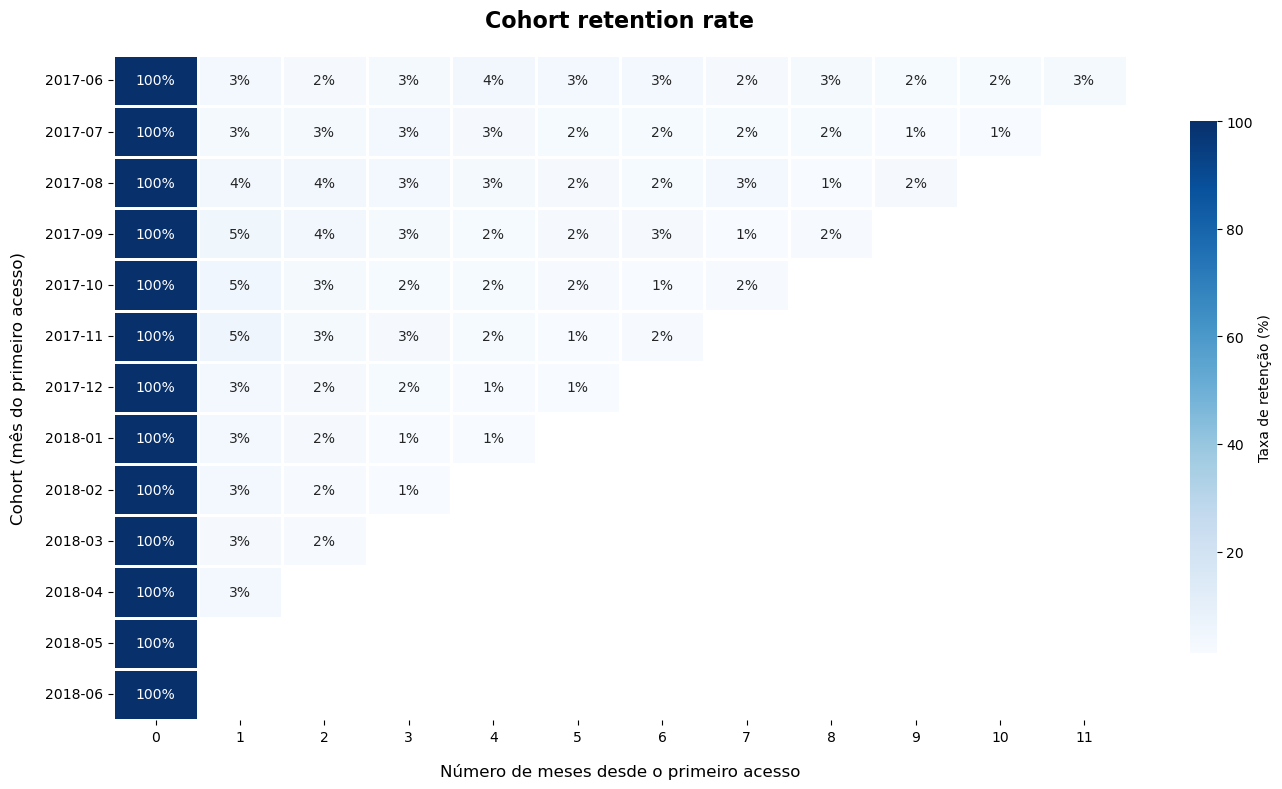

In [113]:
# Criando a tabela de coorte para taxa de retenção mensal

# Criando coluna com o mês da primeira compra para cada usuário
first_purchase = orders.groupby('Uid')['Buy Ts'].min().dt.to_period('M')
orders['FirstPurchaseMonth'] = orders['Uid'].map(first_purchase)

# Criando uma coluna com o número de meses desde a primeira compra
orders['OrderMonth'] = orders['Buy Ts'].dt.to_period('M')
orders['MonthsSinceFirstPurchase'] = (orders['OrderMonth'] - orders['FirstPurchaseMonth']).apply(lambda x: x.n)

# Criando a tabela de coorte
cohort = orders.groupby(['FirstPurchaseMonth', 'MonthsSinceFirstPurchase'])['Uid'].nunique().unstack(fill_value=0)
cohort = cohort.divide(cohort.iloc[:, 0], axis=0) * 100

# Criando array de anotações com formato de percentual
annot_data = np.empty_like(cohort, dtype=object)
for i in range(cohort.shape[0]):
    for j in range(cohort.shape[1]):
        if cohort.iloc[i, j] > 0:
            annot_data[i, j] = f'{cohort.iloc[i, j]:.0f}%'
        else:
            annot_data[i, j] = ''

# Visualizando a tabela de coorte
plt.figure(figsize=(14, 8))
sns.heatmap(cohort, annot=annot_data, fmt='', cmap='Blues', cbar_kws={'label': 'Taxa de retenção (%)', 'shrink': 0.8}, mask=(cohort == 0), linewidths=1, linecolor='white')
plt.title('Cohort retention rate', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Cohort (mês do primeiro acesso)', fontsize=12, labelpad=14)
plt.xlabel('Número de meses desde o primeiro acesso', fontsize=12, labelpad=14)
plt.gca().set_facecolor('white')
plt.tight_layout()
plt.show()

In [114]:
# Volume médio por compra - quanto um usuário gasta por compra
average_order_value = orders['Revenue'].describe()
print('Volume médio por compra:')
print()
print(average_order_value)

Volume médio por compra:

count    50415.000000
mean         4.999647
std         21.818359
min          0.000000
25%          1.220000
50%          2.500000
75%          4.890000
max       2633.280000
Name: Revenue, dtype: float64


In [115]:
# Pedido por usuário com mês
first_orders_df = orders.groupby('Uid').agg({'Buy Ts': 'min'}).reset_index().rename(columns={'Buy Ts': 'first_purchase'})
first_orders_df['first_purchase_month'] = first_orders_df['first_purchase'].dt.to_period('M')

print('Primeiros pedidos por usuário:')
display(first_orders_df.head())

# Merge com Source ID
user_source = visits[['Uid', 'Source Id']].drop_duplicates()
first_orders_df = pd.merge(first_orders_df, user_source, on='Uid')

print('\nPrimeiros pedidos com Source ID:')
display(first_orders_df.head())

# Receita mensal por usuário
orders['month'] = orders['Buy Ts'].dt.to_period('M')
revenue_df = orders.groupby(['Uid', 'month']).agg({'Revenue': 'sum'}).reset_index()
buyers = first_orders_df.merge(revenue_df, on='Uid')

print('\nReceita por usuário e mês:')
display(buyers.head())

# Preparando dados de custos
costs['month'] = costs['dt'].dt.to_period('M')

# Agregando receita e custos por source e mês
revenue_grouped_df = buyers.groupby(['Source Id', 'month']).agg({'Revenue': 'sum'}).reset_index()
costs_grouped_df = costs.groupby(['source_id', 'month']).agg({'costs': 'sum'}).reset_index().rename(columns={'source_id': 'Source Id'})

# Merge final
report = pd.merge(
    costs_grouped_df, 
    revenue_grouped_df, 
    left_on=['Source Id', 'month'], 
    right_on=['Source Id', 'month'],
    how='outer'
).fillna(0)

report = report.sort_values(['Source Id', 'month'])

print('\n\n=== DATAFRAME FINAL CONSOLIDADO ===')
display(report.head(20))
print(f'\nShape: {report.shape}')
print(f'\nColunas: {report.columns.tolist()}')

Primeiros pedidos por usuário:


,Uid,first_purchase,first_purchase_month
0,313578113262317,2018-01-03 21:51:00,2018-01
1,1575281904278712,2017-06-03 10:13:00,2017-06
2,2429014661409475,2017-10-11 18:33:00,2017-10
3,2464366381792757,2018-01-28 15:54:00,2018-01
4,2551852515556206,2017-11-24 10:14:00,2017-11



Primeiros pedidos com Source ID:


,Uid,first_purchase,first_purchase_month,Source Id
0,313578113262317,2018-01-03 21:51:00,2018-01,2
1,1575281904278712,2017-06-03 10:13:00,2017-06,10
2,2429014661409475,2017-10-11 18:33:00,2017-10,3
3,2464366381792757,2018-01-28 15:54:00,2018-01,5
4,2551852515556206,2017-11-24 10:14:00,2017-11,5



Receita por usuário e mês:


,Uid,first_purchase,first_purchase_month,Source Id,month,Revenue
0,313578113262317,2018-01-03 21:51:00,2018-01,2,2018-01,0.55
1,1575281904278712,2017-06-03 10:13:00,2017-06,10,2017-06,3.05
2,2429014661409475,2017-10-11 18:33:00,2017-10,3,2017-10,73.33
3,2464366381792757,2018-01-28 15:54:00,2018-01,5,2018-01,2.44
4,2551852515556206,2017-11-24 10:14:00,2017-11,5,2017-11,10.99




=== DATAFRAME FINAL CONSOLIDADO ===


,Source Id,month,costs,Revenue
0,1,2017-06,1125.61,2563.84
1,1,2017-07,1072.88,3947.25
2,1,2017-08,951.81,3325.64
3,1,2017-09,1502.01,8193.42
4,1,2017-10,2315.75,11466.14
5,1,2017-11,2445.16,11528.95
6,1,2017-12,2341.20,18814.15
7,1,2018-01,2186.18,7643.43
8,1,2018-02,2204.48,8896.29
9,1,2018-03,1893.09,10899.34



Shape: (86, 4)

Colunas: ['Source Id', 'month', 'costs', 'Revenue']


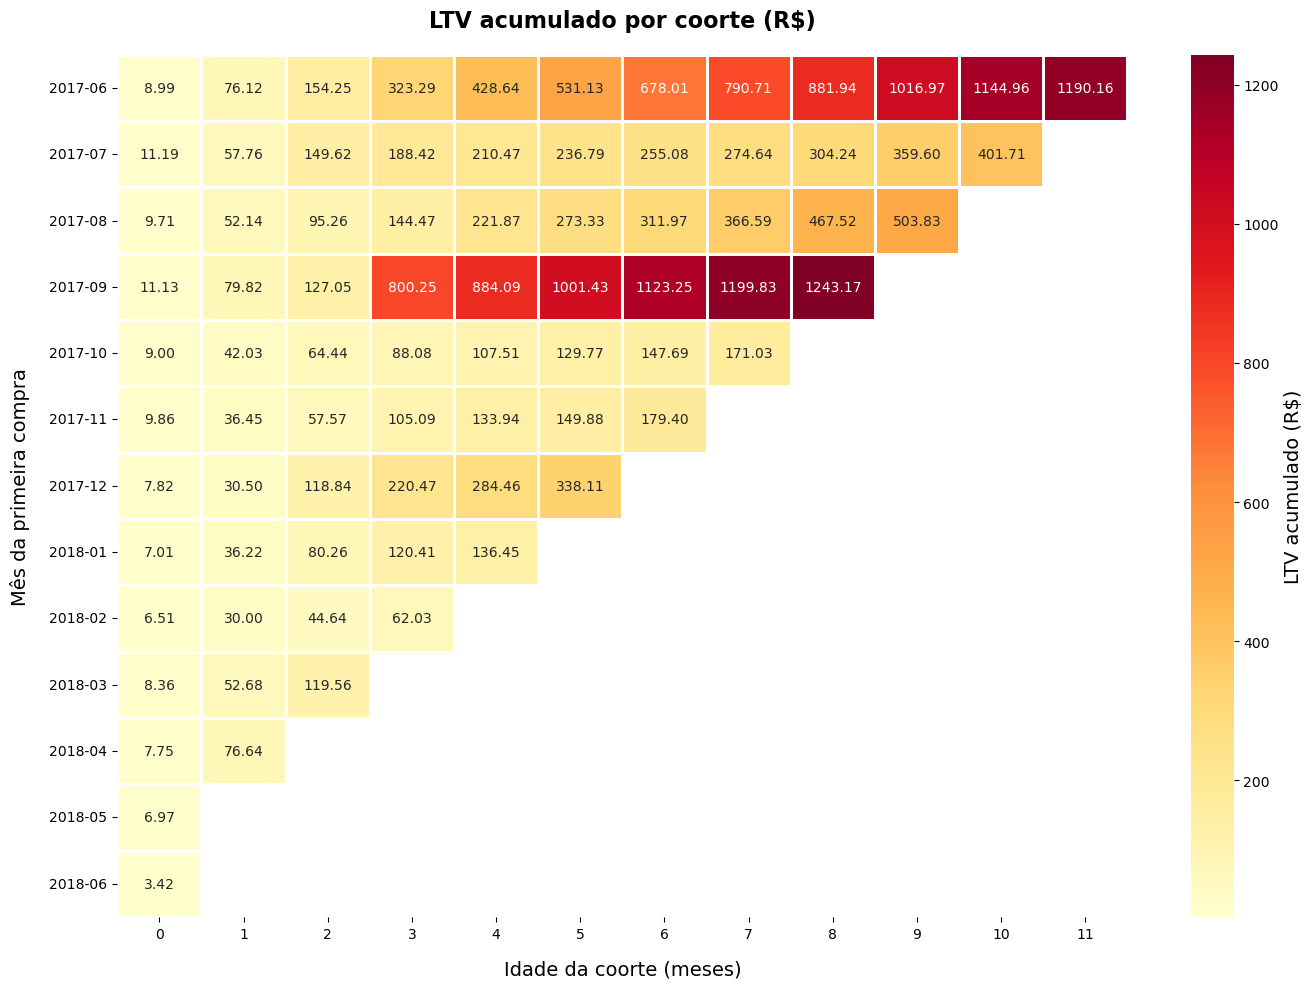

In [116]:
# Preparando dados para LTV por cohort
# Vou usar buyers dataframe que já tem first_purchase_month e dados de receita

# Calculando idade da cohort (meses desde primeira compra)
buyers['age'] = (buyers['month'] - buyers['first_purchase_month']).apply(lambda x: x.n)

# Calculando LTV por usuário (Revenue por usuário e mês)
ltv_data = buyers[['Uid', 'first_purchase_month', 'age', 'Revenue']].copy()

# Agregando LTV (receita média por usuário, por cohort e age)
ltv_by_cohort = ltv_data.groupby(['first_purchase_month', 'age', 'Uid'])['Revenue'].sum().reset_index()
ltv_by_cohort['ltv'] = ltv_by_cohort['Revenue']

# Criando pivot table com LTV acumulado por cohort
output = ltv_by_cohort.pivot_table(
    index='first_purchase_month',
    columns='age',
    values='ltv',
    aggfunc='mean'
)

# LTV acumulado
ltv_acumulado = output.cumsum(axis=1).round(2).fillna('')

# Visualizar como heatmap
fig, ax = plt.subplots(figsize=(14, 10))
heatmap = sns.heatmap(
    output.cumsum(axis=1).round(2), 
    annot=True, 
    fmt='.2f', 
    cmap='YlOrRd', 
    cbar_kws={'label': 'LTV acumulado (R$)'},
    linewidths=1, 
    linecolor='white',
    ax=ax
)

# Ajustando o tamanho da fonte da label do colorbar
heatmap.collections[0].colorbar.ax.yaxis.label.set_size(14)

# Ajustando a rotação do eixo Y para 0 (horizontal) e a barra acompanha a altura total
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

ax.set_title('LTV acumulado por coorte (R$)', fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('Mês da primeira compra', fontsize=14, labelpad=14)
ax.set_xlabel('Idade da coorte (meses)', fontsize=14, labelpad=14)

plt.tight_layout()
plt.show()

### Conclusões sobre quantidade de pedidos, volume médio de compra e LTV

- Ao analisar a quantidade de pedidos por usuário, descobrimos que 30.231 usuários são one-time buyers (compraram apenas uma vez), refletindo um percentual de 82.8% do total de usuários convertidos.

- Isso evidencia um problema de fidelizaçao e consequentemente um grande potencial de receita não explorado, apenas ~17% dos clientes retornam para comprar novamente (baixa retenção).

- O cliente gasta, em média, cerca de $5 por compra, o que indica um ticket médio relativamente baixo.

- Olhando para a mediana, temos um resultado ainda mais crítico, metade dos clientes gasta $2.50 ou menos por compra.

- Essa distribuição assimétrica nos mostra que poucos clientes fazem compras de alto valor.

- 75% dos clientes gastam pouco, até $4.89.

- A média de gastos por cliente é 'puxada' para cima pelos outliers (valor máximo de $2.633).

- Foi importante trazer dois tipos de LTV, um com base na média e outro com base na mediana:

   - Tendo em vista a já mencionada assimetria da distribuição, a mediana é mais representativa, pois a média está sendo 'inflada' por poucos clientes que gastam muito (como o que gastou $2.633). Isso não representa a realidade da maioria dos clientes.
   
   - Contudo, o cálculo do LTV com base na média ainda é viável para fins de receita total e projeções financeiras.
   
   - O LTV com base na mediana trouxe um resultado de $3.45, útil para planejamento e estratégias focadas na maioria dos clientes.

## Análise de custos e ROI

In [117]:
# Somando custos e visualizando gastos por origem e gastos ao longo do tempo
total_costs = costs['costs'].sum()
print(f'No período analisado, o gasto total da Y.Afisha com marketing é de ${total_costs:,.2f}')

No período analisado, o gasto total da Y.Afisha com marketing é de $329,131.62


In [118]:
# Visualizando a origem dos gastos
origin_costs = costs.groupby('source_id')['costs'].sum().sort_values(ascending=False)
print('Gastos por origem:')
print()
print(origin_costs)

Gastos por origem:

source_id
3     141321.63
4      61073.60
5      51757.10
2      42806.04
1      20833.27
10      5822.49
9       5517.49
Name: costs, dtype: float64


In [119]:
# Gastos mensais ao longo do tempo
costs['month'] = costs['dt'].dt.to_period('M')
monthly_costs = costs.groupby('month')['costs'].sum()
print('Gastos mensais:')
print()
print(monthly_costs)

Gastos mensais:

month
2017-06    18015.00
2017-07    18240.59
2017-08    14790.54
2017-09    24368.91
2017-10    36322.88
2017-11    37907.88
2017-12    38315.35
2018-01    33518.52
2018-02    32723.03
2018-03    30415.27
2018-04    22289.38
2018-05    22224.27
Freq: M, Name: costs, dtype: float64


In [120]:
# Contando usuários únicos que converteram por source (usando dados consolidados corretos)
converted_users_by_source = buyers.groupby('Source Id')['Uid'].nunique()
print('Usuários convertidos por origem:')
print()
print(converted_users_by_source)

Usuários convertidos por origem:

Source Id
1      7138
2      7305
3     13846
4     14253
5     10156
7         1
9      2793
10     1773
Name: Uid, dtype: int64


In [121]:
# Calculando o CAC

# CAC = custos totais por source ÷ usuários convertidos por source
costs_by_source = report.groupby('Source Id')['costs'].sum()
cac_per_origin = costs_by_source / converted_users_by_source

print('CAC por origem:')
print()
print(f'{cac_per_origin.round(2)}')

CAC por origem:

Source Id
1      2.92
2      5.86
3     10.21
4      4.28
5      5.10
7      0.00
9      1.98
10     3.28
dtype: float64


In [122]:
# Visualizando o ROI (return on investment)

# Receita total por origem
revenue_by_source = report.groupby('Source Id')['Revenue'].sum()
revenue_per_origin = revenue_by_source

print('Receita por origem:')
print()
print(revenue_per_origin.round(2))

# ROI = (receita - custo) / custo * 100
roi = (revenue_per_origin - costs_by_source) / costs_by_source * 100
print()

print('\nRetorno do investimento - ROI:')
print()
print(roi)

Receita por origem:

Source Id
1     101631.38
2     113524.51
3     119193.48
4     119899.47
5     111532.65
7          1.22
9      18809.68
10      8218.72
Name: Revenue, dtype: float64


Retorno do investimento - ROI:

Source Id
1     387.832107
2     165.206756
3     -15.658006
4      96.319637
5     115.492464
7            inf
9     240.910088
10     41.154729
dtype: float64


In [123]:
# Criando DataFrame para melhor visualização (tratando infinitos e ordenando por ROI)

print('\n' + '='*45)
title = 'ROI por origem'
print(title.center(45))    
print('='*45 + '\n')

# Tratar infinitos no ROI (quando custos = 0, Source 7)
roi_treated = roi.copy()
roi_treated = roi_treated.replace([np.inf, -np.inf], np.nan)  # Converter inf para NaN temporariamente

# Criar DataFrame com valores formatados
roi_analysis = pd.DataFrame({
    'Source ID': costs_by_source.index,
    'Custo': costs_by_source.apply(lambda x: f'{x:,.2f}' if pd.notna(x) and x > 0 else 'Sem custo').values,
    'Receita': revenue_per_origin.apply(lambda x: f'{x:,.2f}' if pd.notna(x) else 'N/A').values,
})

# Adicionar ROI com tratamento para infinitos
roi_analysis['ROI'] = roi_treated.apply(
    lambda x: f'{x:,.2f}%' if pd.notna(x) and not np.isnan(x) else 'Sem custo'
).values

# Adicionar coluna numérica auxiliar para ordenação
roi_analysis['ROI_numeric'] = roi_treated.fillna(-999).values

# Ordenar por ROI em ordem DECRESCENTE
roi_analysis = roi_analysis.sort_values('ROI_numeric', ascending=False)

# Remover coluna auxiliar de ordenação
roi_analysis = roi_analysis.drop('ROI_numeric', axis=1)

display(roi_analysis.reset_index(drop=True).style
    .set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'center'), ('font-weight', 'bold')]},
    {'selector': 'td', 'props': [('text-align', 'center')]}]))


                ROI por origem               



,Source ID,Custo,Receita,ROI
0,1,"20,833.27","101,631.38",387.83%
1,9,"5,517.49","18,809.68",240.91%
2,2,"42,806.04","113,524.51",165.21%
3,5,"51,757.10","111,532.65",115.49%
4,4,"61,073.60","119,899.47",96.32%
5,10,"5,822.49","8,218.72",41.15%
6,3,"141,321.63","119,193.48",-15.66%
7,7,Sem custo,1.22,Sem custo


In [ ]:
# Preparando dados para ROMI e ROI por cohort
# Calculando LTV, CAC, Custos e Receita por cohort (mês da primeira compra)

# 0. Criando Series de custos indexada por Source ID (necessária para cálculos de cohort)
costs_clean = costs_by_source.copy()

# 1. LTV por cohort: receita total / número de usuários únicos por cohort
ltv_cohort_agg = buyers.groupby('first_purchase_month', as_index=True)[['Revenue', 'Uid']].agg({
    'Revenue': 'sum',
    'Uid': 'nunique'
})
ltv_by_cohort_calc = ltv_cohort_agg['Revenue'] / ltv_cohort_agg['Uid']

# 2. CAC por cohort: custo total / número de usuários únicos que iniciaram compra naquele mês
cac_cohort_sources = buyers.groupby('first_purchase_month')['Source Id'].apply(lambda x: list(x.unique()))
cac_cohort_users = buyers.groupby('first_purchase_month')['Uid'].nunique()
cac_by_cohort_calc = pd.Series(index=cac_cohort_sources.index, dtype=float)
for cohort in cac_cohort_sources.index:
    cohort_cost = costs_clean[costs_clean.index.isin(cac_cohort_sources[cohort])].sum()
    cac_by_cohort_calc[cohort] = cohort_cost / cac_cohort_users[cohort] if cac_cohort_users[cohort] > 0 else 0

# 3. Custos totais por cohort
costs_by_cohort_calc = pd.Series(index=cac_cohort_sources.index, dtype=float)
for cohort in cac_cohort_sources.index:
    costs_by_cohort_calc[cohort] = costs_clean[costs_clean.index.isin(cac_cohort_sources[cohort])].sum()

# 4. Receita total por cohort
revenue_by_cohort = buyers.groupby('first_purchase_month')['Revenue'].sum()

# 5. DataFrame com cohorts únicos
romi_cohort_df = pd.DataFrame({
    'Cohort (mês)': sorted(buyers['first_purchase_month'].unique())
}).reset_index(drop=True)

# 6. Criando DataFrame formatado para exibição de ROMI por cohort
romi_cohort_display = pd.DataFrame({
    'Cohort (mês)': romi_cohort_df['Cohort (mês)'].values,
    'LTV': [f'${ltv_by_cohort_calc.get(c, 0):,.2f}' for c in romi_cohort_df['Cohort (mês)'].values],
    'CAC': [f'${cac_by_cohort_calc.get(c, 0):,.2f}' for c in romi_cohort_df['Cohort (mês)'].values],
    'ROMI': [(ltv_by_cohort_calc.get(c, 0) / cac_by_cohort_calc.get(c, 1)) if cac_by_cohort_calc.get(c, 0) > 0 else 0 
             for c in romi_cohort_df['Cohort (mês)'].values]
})
romi_cohort_display['ROMI'] = romi_cohort_display['ROMI'].apply(lambda x: f'{x:.2f}x' if x > 0 else 'N/A')

print('Dados de cohort preparados para análise de ROMI e ROI')


Dados de cohort preparados para análise de ROMI e ROI


In [181]:
# ROMI por cohort
print('\n' + '='*55)
title = 'ROMI por cohort'
print(title.center(55))
print('='*55 + '\n')
display(romi_cohort_display.reset_index(drop=True))

# ROI por cohort (percentual)
print('\n' + '='*50)
title = 'ROI por cohort (mês da primeira compra)'
print(title.center(50))
print('='*50 + '\n')

# Calculando ROI por cohort: (LTV - CAC) / CAC * 100
roi_by_cohort_calc = ((ltv_by_cohort_calc - cac_by_cohort_calc) / cac_by_cohort_calc * 100).round(2)

# Filtrando apenas linhas válidas (onde cohort está em romi_cohort_df)
roi_cohort_df = pd.DataFrame({
    'Cohort (mês)': romi_cohort_df['Cohort (mês)'].values,
    'Receita Total': [revenue_by_cohort.get(c, 0) for c in romi_cohort_df['Cohort (mês)'].values],
    'Custos Total': [costs_by_cohort_calc.get(c, 0) for c in romi_cohort_df['Cohort (mês)'].values],
    'ROI (%)': [roi_by_cohort_calc.get(c, np.nan) for c in romi_cohort_df['Cohort (mês)'].values]
})

# Formatação para exibição
roi_cohort_display = roi_cohort_df.copy()
roi_cohort_display['Receita Total'] = roi_cohort_display['Receita Total'].apply(lambda x: f'${x:,.2f}')
roi_cohort_display['Custos Total'] = roi_cohort_display['Custos Total'].apply(lambda x: f'${x:,.2f}')
roi_cohort_display['ROI (%)'] = roi_cohort_display['ROI (%)'].apply(lambda x: f'{x:,.2f}%' if pd.notna(x) else 'N/A')

display(roi_cohort_display.reset_index(drop=True))


                    ROMI por cohort                    



,Cohort (mês),LTV,CAC,ROMI
0,2017-06,$42.21,$162.69,0.26x
1,2017-07,$20.14,$171.16,0.12x
2,2017-08,$23.04,$240.24,0.10x
3,2017-09,$45.25,$127.52,0.35x
4,2017-10,$13.08,$75.84,0.17x
5,2017-11,$14.37,$80.65,0.18x
6,2017-12,$14.41,$75.09,0.19x
7,2018-01,$9.81,$97.58,0.10x
8,2018-02,$7.69,$90.15,0.09x
9,2018-03,$10.59,$93.16,0.11x



     ROI por cohort (mês da primeira compra)      



,Cohort (mês),Receita Total,Custos Total,ROI (%)
0,2017-06,"$85,388.70","$329,131.62",-74.06%
1,2017-07,"$38,721.63","$329,131.62",-88.24%
2,2017-08,"$31,558.17","$329,131.62",-90.41%
3,2017-09,"$116,802.97","$329,131.62",-64.51%
4,2017-10,"$56,770.52","$329,131.62",-82.75%
5,2017-11,"$58,643.95","$329,131.62",-82.18%
6,2017-12,"$63,144.13","$329,131.62",-80.81%
7,2018-01,"$33,091.20","$329,131.62",-89.95%
8,2018-02,"$28,072.58","$329,131.62",-91.47%
9,2018-03,"$37,399.13","$329,131.62",-88.64%


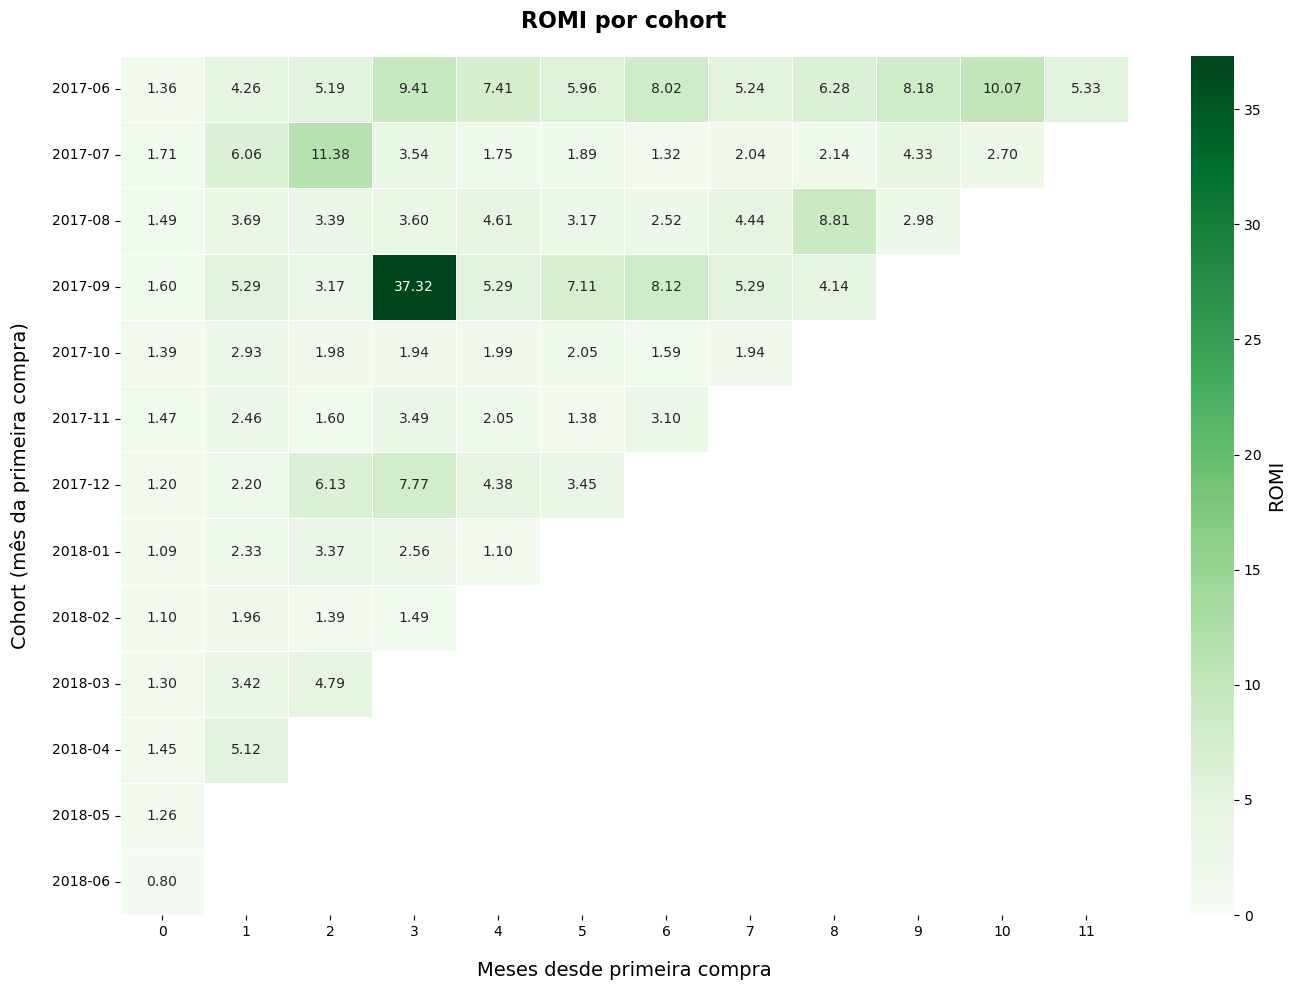

In [126]:
# Pivot table detalhada de ROMI por cohort e idade (meses desde primeira compra)

# Primeiro, vamos recalcular o age para cada registro
buyers_for_romi = buyers.copy()
buyers_for_romi['age'] = (buyers_for_romi['month'] - buyers_for_romi['first_purchase_month']).apply(lambda x: x.n if hasattr(x, 'n') else 0)

# Agregando LTV e CAC por cohort, age e source
romi_detailed = buyers_for_romi.groupby(['first_purchase_month', 'age', 'Source Id']).agg({
    'Revenue': 'sum',
    'Uid': 'nunique'
}).reset_index()

romi_detailed.columns = ['cohort', 'age', 'source_id', 'revenue', 'users']

# Adicionar CAC por source
romi_detailed['cac'] = romi_detailed['source_id'].map(cac_per_origin)

# Calcular LTV médio
romi_detailed['ltv'] = romi_detailed['revenue'] / romi_detailed['users']

# Calcular ROMI apenas para linhas com CAC > 0 (excluir Source 7 que tem CAC = 0)
romi_detailed['romi'] = romi_detailed.apply(
    lambda row: row['ltv'] / row['cac'] if row['cac'] > 0 else np.nan, 
    axis=1
)

# Criar pivot table de ROMI
romi_pivot_table = romi_detailed.pivot_table(
    index='cohort',
    columns='age',
    values='romi',
    aggfunc='mean'
).round(2)

# Criando heatmap
fig, ax = plt.subplots(figsize=(14, 10))
heatmap = sns.heatmap(
    romi_pivot_table, 
    annot=True, 
    fmt='.2f', 
    cmap='Greens', 
    cbar_kws={'label': 'ROMI', 'shrink': 1.0},
    linewidths=0.5, 
    linecolor='white',
    vmin=0,
    ax=ax
)

# Ajustando o tamanho da fonte da label do colorbar
heatmap.collections[0].colorbar.ax.yaxis.label.set_size(14)

# Ajustando a rotação do eixo Y para 0 (horizontal) e a barra acompanha a altura total
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

ax.set_title('ROMI por cohort', fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('Cohort (mês da primeira compra)', fontsize=14, labelpad=16)
ax.set_xlabel('Meses desde primeira compra', fontsize=14, labelpad=16)
plt.tight_layout()
plt.show()

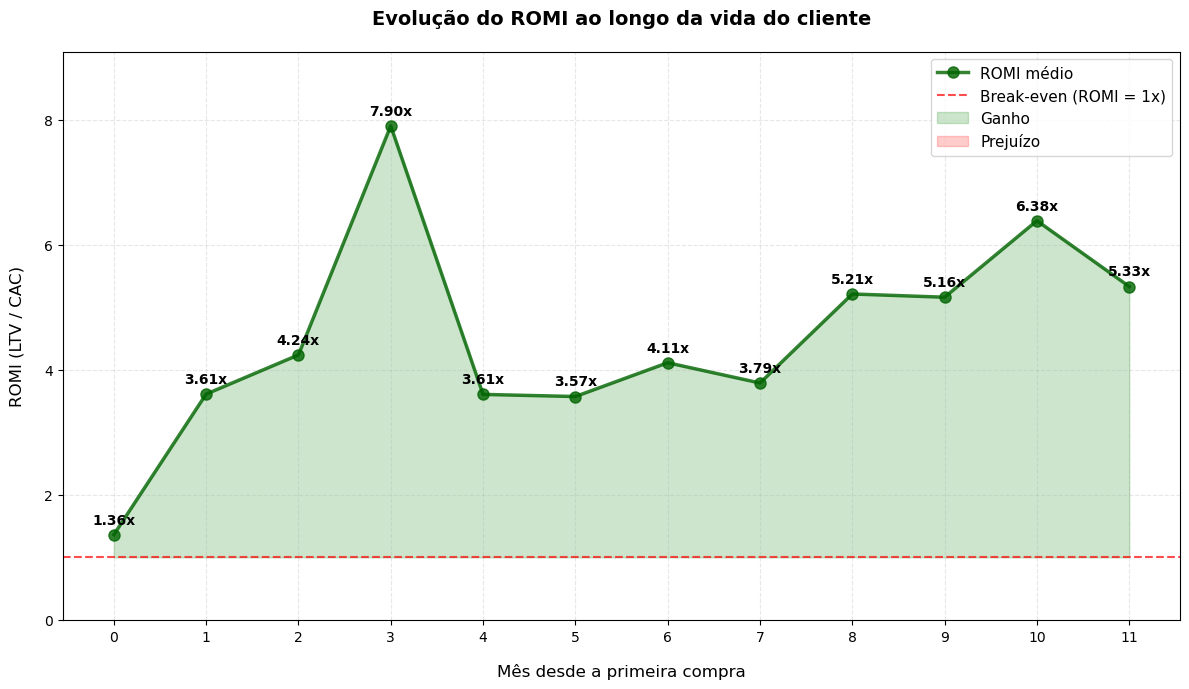

In [137]:
# Visualizar ROMI ao longo do tempo em gráfico

#Gráfico de tendência de ROMI

# Calculando ROMI médio por mês (age)
romi_by_age = romi_detailed[romi_detailed['cac'] > 0].groupby('age')['romi'].mean()

# Criando gráfico
fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(romi_by_age.index, romi_by_age.values, marker='o', linewidth=2.5, 
        alpha=0.8, markersize=8, color='darkgreen', label='ROMI médio')

ax.axhline(y=1, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Break-even (ROMI = 1x)')

# Preenchimento abaixo da linha
ax.fill_between(romi_by_age.index, romi_by_age.values, 1, where=(romi_by_age.values >= 1), 
                alpha=0.2, color='green', label='Ganho')
ax.fill_between(romi_by_age.index, romi_by_age.values, 1, where=(romi_by_age.values < 1), 
                alpha=0.2, color='red', label='Prejuízo')

# Adicionando valores nos pontos
for x, y in zip(romi_by_age.index, romi_by_age.values):
    ax.annotate(f'{y:.2f}x', xy=(x, y), xytext=(0, 8), 
                textcoords='offset points', ha='center', fontweight='bold', fontsize=10)

ax.set_xlabel('Mês desde a primeira compra', fontsize=12, labelpad=14)
ax.set_ylabel('ROMI (LTV / CAC)', fontsize=12, labelpad=14)
ax.set_title('Evolução do ROMI ao longo da vida do cliente', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(range(0, int(romi_by_age.index.max()) + 1, 1))
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=11, loc='upper right')
ax.set_ylim(0, max(romi_by_age.values) * 1.15)

plt.tight_layout()
plt.show()

### Conclusões sobre ROMI

1. ROMI inicial (mês 0): 1.32x
   → Significa que cada $1 gasto em aquisição retorna $1.32 na primeira compra

2. ROMI em repeat purchases (mês 1+): 3.61x a 7.90x
   → Clientes que retornam geram um ROMI significativamente maior

3. Melhor performance: mês 3 com ROMI de 7.90x
   → Indica que clientes que voltam 3 meses depois geram 7.9x de retorno

4. Importância da retenção:
   → O foco em manter clientes retornando é crítico
   → Um cliente que volta mesmo 1 mês depois retorna 2.7x mais que na primeira compra

### Criação de gráficos

In [128]:
# Definindo variáveis de LTV baseadas no volume médio por compra
ltv_mean = average_order_value['mean']  # Média: $4.99
ltv_value = ltv_mean  # Valor para uso nos gráficos

# Preparando dados para gráfico1

# Dados de CAC por origem (cac_per_origin)
cac_data = {
    1: 2.92,
    2: 5.86, 
    3: 10.21,
    4: 4.28,
    5: 5.10,
    9: 1.98,
    10: 3.28
}

# Criando DataFrame para o gráfico
df_cac_ltv = pd.DataFrame({
    'Source': list(cac_data.keys()),
    'CAC': list(cac_data.values()),
    'LTV': [ltv_value] * len(cac_data)  # LTV é o mesmo para todos
})

print('Dados prontos para o gráfico1:')
print()
display(df_cac_ltv)

Dados prontos para o gráfico1:



,Source,CAC,LTV
0,1,2.92,4.999647
1,2,5.86,4.999647
2,3,10.21,4.999647
3,4,4.28,4.999647
4,5,5.10,4.999647
5,9,1.98,4.999647
6,10,3.28,4.999647


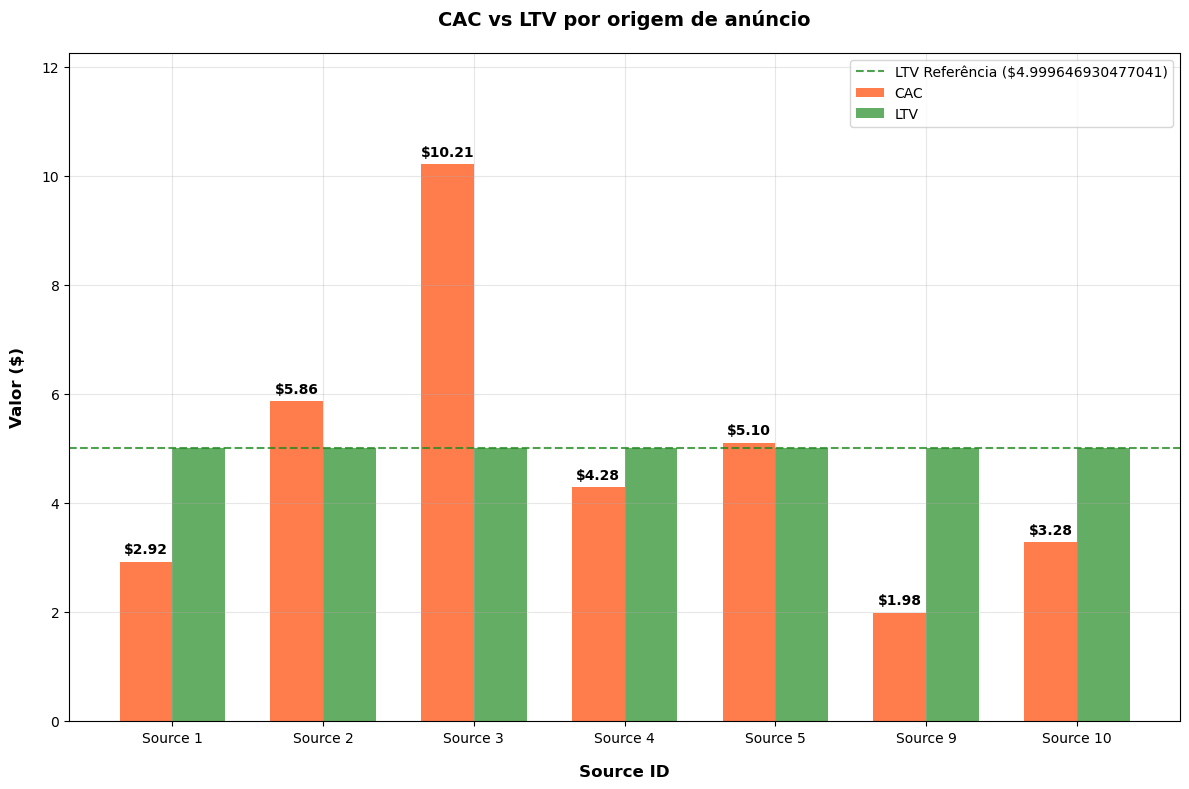

In [129]:
# Configurando o gráfico1
fig, ax = plt.subplots(figsize=(12, 8))

# Posições das barras
x = np.arange(len(df_cac_ltv))
width = 0.35

# Criando as barras
bars_cac = ax.bar(x - width/2, df_cac_ltv['CAC'], width, 
                  label='CAC', color='orangered', alpha=0.7)
bars_ltv = ax.bar(x + width/2, df_cac_ltv['LTV'], width, 
                  label='LTV', color='forestgreen', alpha=0.7)

# Personalizando o gráfico
ax.set_xlabel('Source ID', fontsize=12, fontweight='bold', labelpad=14)
ax.set_ylabel('Valor ($)', fontsize=12, fontweight='bold', labelpad=12)
ax.set_title('CAC vs LTV por origem de anúncio', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels([f'Source {s}' for s in df_cac_ltv['Source']])

# Adicionando linha de referência do LTV
ax.axhline(y=ltv_value, color='forestgreen', linestyle='--', alpha=0.8, 
           label=f'LTV Referência (${ltv_value})')

# Adicionando valores nas barras
for bar in bars_cac:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'${height:.2f}', ha='center', va='bottom', fontweight='bold')

ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, max(df_cac_ltv['CAC'].max(), ltv_value) * 1.2)

plt.tight_layout()
plt.show()

In [130]:
# Preparando dados para gráfico2

# Dados de receita mensal
orders['month'] = orders['Buy Ts'].dt.to_period('M')
monthly_revenue = orders.groupby('month')['Revenue'].sum()

# Combinando dados de gastos e receita mensal
df_monthly = pd.DataFrame({
    'Gastos': monthly_costs,
    'Receita': monthly_revenue
})

# Preenchendo valores ausentes com 0 (caso algum mês não tenha dados)
df_monthly = df_monthly.fillna(0)

print('Dados prontos para o gráfico2:')
print()
display(df_monthly)

Dados prontos para o gráfico2:



,Gastos,Receita
month,,
2017-06,18015.00,9557.49
2017-07,18240.59,12539.47
2017-08,14790.54,8758.78
2017-09,24368.91,18345.51
2017-10,36322.88,27987.70
2017-11,37907.88,27069.93
2017-12,38315.35,36388.60
2018-01,33518.52,19417.13
2018-02,32723.03,25560.54


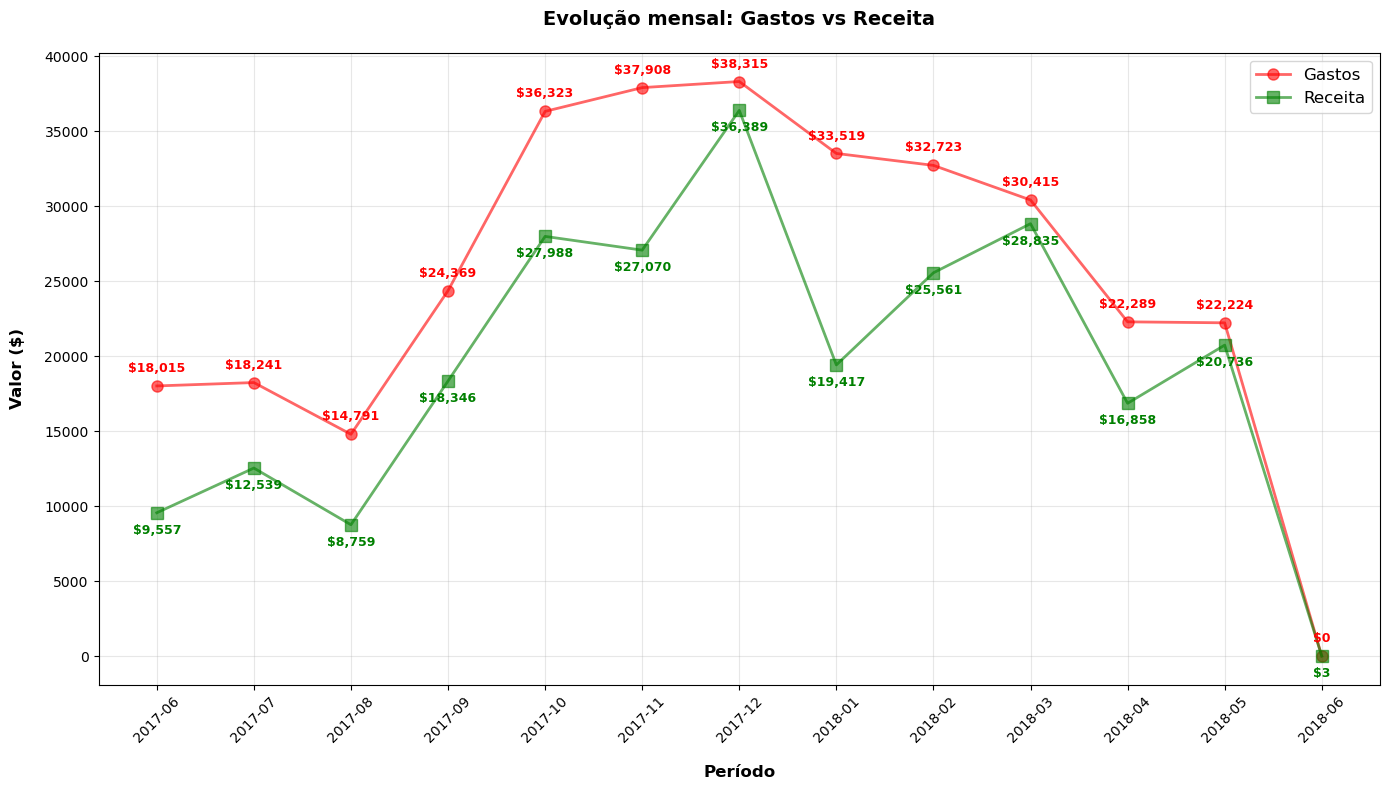

In [131]:
# Criando o gráfico2 (evolução mensal)
fig, ax = plt.subplots(figsize=(14, 8))

# Convertendo o índice para string para melhor visualização
months = [str(month) for month in df_monthly.index]

# Criando as linhas
ax.plot(months, df_monthly['Gastos'], marker='o', linewidth=2, 
        markersize=8, color='red', label='Gastos', alpha=0.6)
ax.plot(months, df_monthly['Receita'], marker='s', linewidth=2, 
        markersize=8, color='green', label='Receita', alpha=0.6)

ax.set_xlabel('Período', fontsize=12, fontweight='bold', labelpad=14)
ax.set_ylabel('Valor ($)', fontsize=12, fontweight='bold', labelpad=14)
ax.set_title('Evolução mensal: Gastos vs Receita', fontsize=14, fontweight='bold', pad=20)

# Adicionando valores nos pontos
for i, (gasto, receita) in enumerate(zip(df_monthly['Gastos'], df_monthly['Receita'])):
    ax.annotate(f'${gasto:,.0f}', (i, gasto), textcoords="offset points", 
                xytext=(0,10), ha='center', fontsize=9, color='red', fontweight='bold')
    ax.annotate(f'${receita:,.0f}', (i, receita), textcoords="offset points", 
                xytext=(0,-15), ha='center', fontsize=9, color='green', fontweight='bold')

plt.xticks(rotation=45)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [132]:
# Preparando dados para gráfico3

# Verificando os tipos de dispositivos disponíveis
print('Dispositivos disponíveis:')
print()
print(visits['Device'].value_counts())

Dispositivos disponíveis:

Device
desktop    262567
touch       96833
Name: count, dtype: int64


In [133]:
# Calculando métricas de conversão por dispositivo

# 1. Usuários únicos por dispositivo
users_by_device = visits.groupby('Device')['Uid'].nunique()
print('Usuários únicos por dispositivo:')
print(users_by_device)

# 2. Usuários convertidos por dispositivo
# Primeiro, vamos identificar quais usuários converteram
converted_users = set(orders['Uid'].unique())

# Agora vamos ver de qual dispositivo esses usuários convertidos vieram
# (considerando a primeira visita de cada usuário)
first_visit_device = visits.groupby('Uid')['Device'].first()
converted_users_device = first_visit_device[first_visit_device.index.isin(converted_users)]
converted_by_device = converted_users_device.value_counts()

print('\nUsuários convertidos por dispositivo:')
print(converted_by_device)

# 3. Taxa de conversão por dispositivo
conversion_rate = (converted_by_device / users_by_device * 100).round(2)
print('\nTaxa de conversão por dispositivo (%):')
print(conversion_rate)

Usuários únicos por dispositivo:
Device
desktop    164523
touch       71345
Name: Uid, dtype: int64

Usuários convertidos por dispositivo:
Device
desktop    29222
touch       7301
Name: count, dtype: int64

Taxa de conversão por dispositivo (%):
Device
desktop    17.76
touch      10.23
dtype: float64


In [134]:
# Organizando dados para o gráfico3
df_device = pd.DataFrame({
    'Device': ['Desktop', 'Touch'],
    'Unique users': [164523, 71345],
    'Converted users': [29222, 7301],
    'Conversion rate': [17.76, 10.23]
})

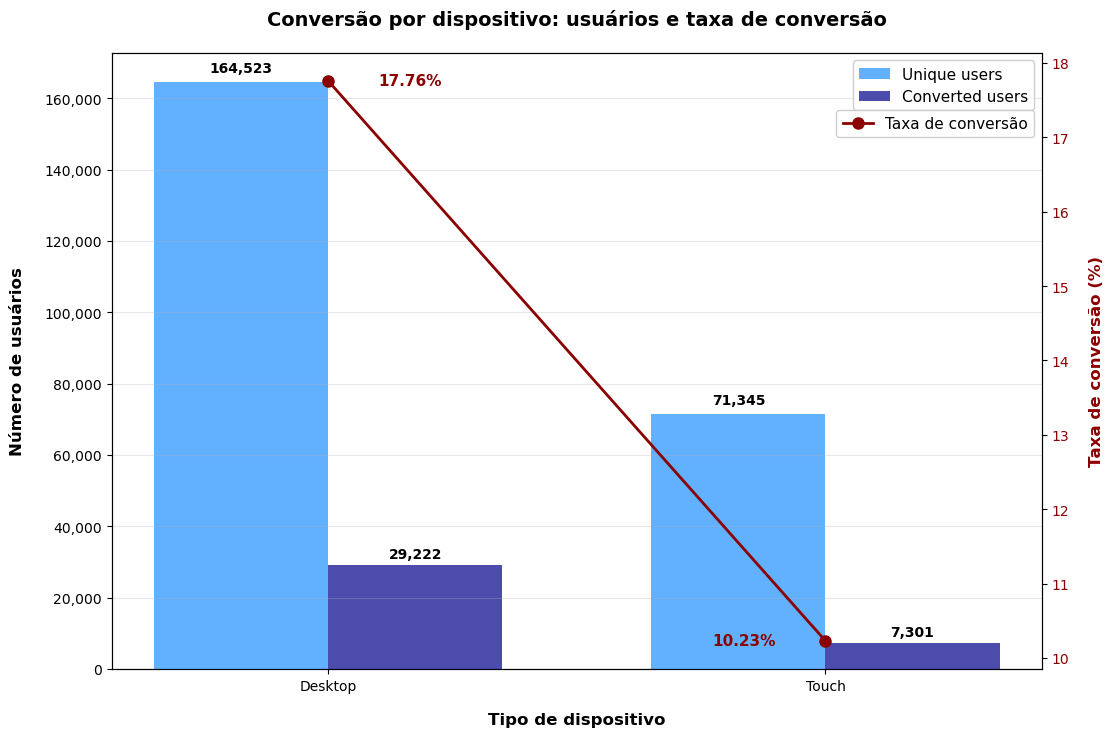

In [ ]:
# Criando o gráfico3
fig, ax1 = plt.subplots(figsize=(12, 8))

# Posições das barras
x = np.arange(len(df_device))
width = 0.35

# Criando as barras para usuários únicos e convertidos
bars1 = ax1.bar(x - width/2, df_device['Unique users'], width, 
                label='Unique users', color='dodgerblue', alpha=0.7)
bars2 = ax1.bar(x + width/2, df_device['Converted users'], width,
                label='Converted users', color='darkblue', alpha=0.7)

ax1.set_xlabel('Tipo de dispositivo', fontsize=12, fontweight='bold', labelpad=14)
ax1.set_ylabel('Número de usuários', fontsize=12, fontweight='bold', labelpad=14)
ax1.set_title('Conversão por dispositivo: usuários e taxa de conversão', 
              fontsize=14, fontweight='bold', pad=20)

# Configurando as posições no eixo X
ax1.set_xticks(x)
ax1.set_xticklabels(df_device['Device'])

# Adicionando valores nas barras
for i, bar in enumerate(bars1):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 2000,
             f'{height:,}', ha='center', va='bottom', fontweight='bold', fontsize=10)

for i, bar in enumerate(bars2):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1000,
             f'{height:,}', ha='center', va='bottom', fontweight='bold', fontsize=10)


# Formatando o eixo Y com separadores de milhares
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

ax1.grid(True, alpha=0.3, axis='y')
ax1.legend(loc='upper right', fontsize=11, framealpha=0.95)

# Criando o segundo eixo Y para a taxa de conversão
ax2 = ax1.twinx()

# Criando a linha da taxa de conversão
line = ax2.plot(x, df_device['Conversion rate'], color='darkred', marker='o', 
                linewidth=2, markersize=8, label='Taxa de conversão')

# Configurando o segundo eixo Y
ax2.set_ylabel('Taxa de conversão (%)', fontsize=12, fontweight='bold', color='darkred', labelpad=14)
ax2.tick_params(axis='y', labelcolor='darkred')

# Adicionando legenda para a linha
ax2.legend(loc='upper right', bbox_to_anchor=(1, 0.92), fontsize=11, framealpha=0.95)

# Adicionando valores na linha e personalizando posição
for i, rate in enumerate(df_device['Conversion rate']):
    # Definindo posição horizontal baseada no valor
    if rate > 15:  # posicionando à direita
        ha_position = 'left'
        x_offset = 0.1
    else:  # posicionando à esquerda
        ha_position = 'right'
        x_offset = -0.1
    

    ax2.text(x[i] + x_offset, rate, f'{rate}%', 
             ha=ha_position, va='center',
             fontweight='bold', fontsize=11, color='darkred')

In [147]:
# Preparando dados para gráfico4 - ROI por origem

# Removendo Source 7 que tem dados insuficientes (NaN ou inf)
roi_clean = roi.replace([np.inf, -np.inf], np.nan).dropna()
costs_clean = origin_costs[origin_costs.index.isin(roi_clean.index)]
revenue_clean = revenue_per_origin[revenue_per_origin.index.isin(roi_clean.index)]

# Alinhando os índices
indices_aligned = costs_clean.index

# Criando DataFrame organizado
df_roi = pd.DataFrame({
    'Source ID': indices_aligned,
    'Custos': costs_clean[indices_aligned].values,
    'Receita': revenue_clean[indices_aligned].values,
    'ROI': roi_clean[indices_aligned].values
})

# Ordenando por ROI decrescente para melhor visualização
df_roi = df_roi.sort_values('ROI', ascending=False).reset_index(drop=True)

print('Dados prontos para o gráfico4:')
print()
display(df_roi)

Dados prontos para o gráfico4:



,Source ID,Custos,Receita,ROI
0,1,20833.27,101631.38,387.832107
1,9,5517.49,18809.68,240.910088
2,2,42806.04,113524.51,165.206756
3,5,51757.10,111532.65,115.492464
4,4,61073.60,119899.47,96.319637
5,10,5822.49,8218.72,41.154729
6,3,141321.63,119193.48,-15.658006


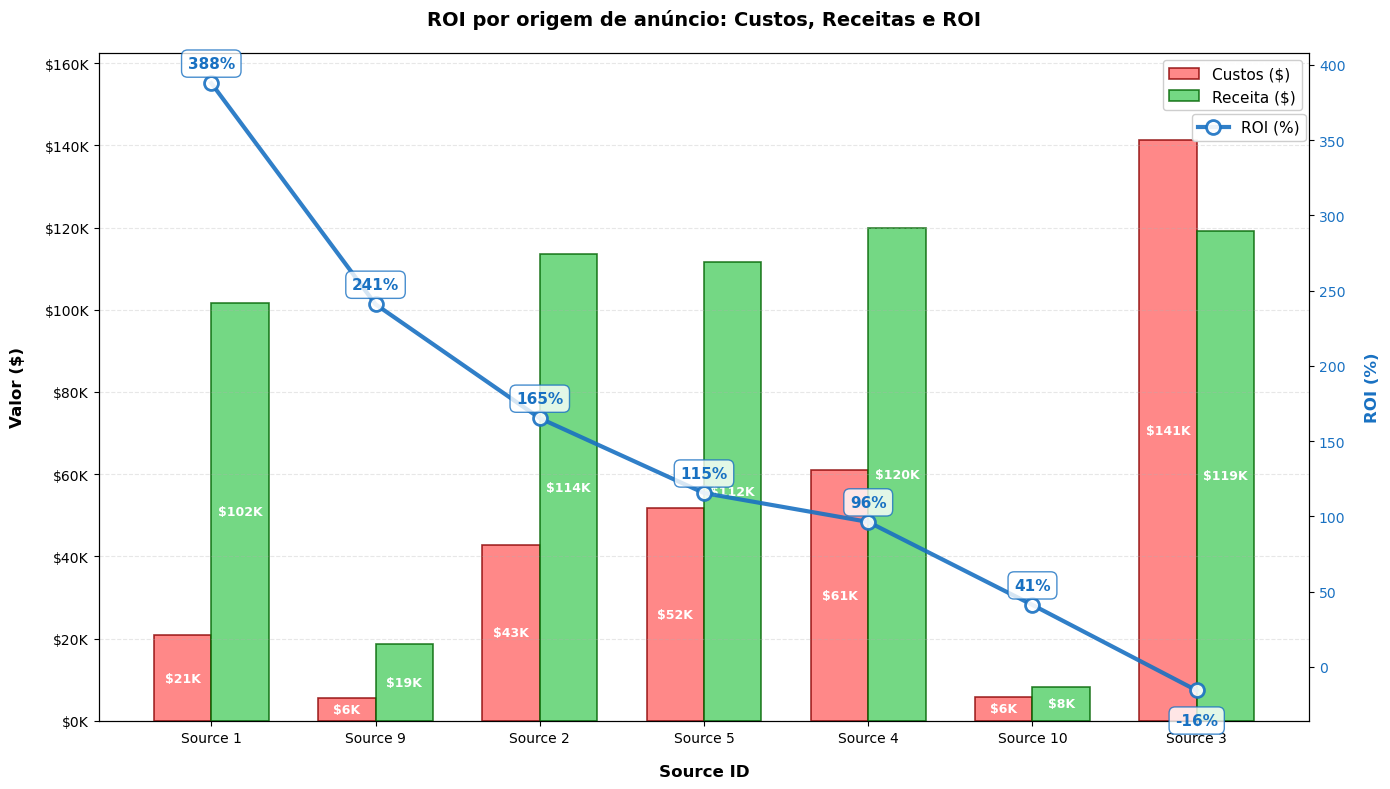

In [169]:
# Criando o gráfico4 - ROI por origem
fig, ax1 = plt.subplots(figsize=(14, 8))

# Posições das barras
x = np.arange(len(df_roi))
width = 0.35

# Criando as barras para custos e receitas
bars_costs = ax1.bar(x - width/2, df_roi['Custos'], width,
                     label='Custos ($)', color='#FF6B6B', alpha=0.8, edgecolor='darkred', linewidth=1.2)
bars_revenue = ax1.bar(x + width/2, df_roi['Receita'], width,
                       label='Receita ($)', color='#51CF66', alpha=0.8, edgecolor='darkgreen', linewidth=1.2)

# Adicionando valores nas barras de custos e receita
for bar in bars_costs:
    height = bar.get_height()
    if height > 0:
        ax1.text(bar.get_x() + bar.get_width()/2., height/2,
                f'${height/1e3:.0f}K', ha='center', va='center',
                fontsize=9, fontweight='bold', color='white')

for bar in bars_revenue:
    height = bar.get_height()
    if height > 0:
        ax1.text(bar.get_x() + bar.get_width()/2., height/2,
                f'${height/1e3:.0f}K', ha='center', va='center',
                fontsize=9, fontweight='bold', color='white')

# Configurando o primeiro eixo Y (valores monetários)
ax1.set_xlabel('Source ID', fontsize=12, fontweight='bold', labelpad=14)
ax1.set_ylabel('Valor ($)', fontsize=12, fontweight='bold', color='black', labelpad=14)
ax1.set_title('ROI por origem de anúncio: Custos, Receitas e ROI',
              fontsize=14, fontweight='bold', pad=20)

# Calculando ylim baseado nos dados reais
max_value = max(df_roi['Custos'].max(), df_roi['Receita'].max())
ax1.set_ylim(0, max_value * 1.15)

# Configurando as posições no eixo X
ax1.set_xticks(x)
ax1.set_xticklabels([f'Source {int(source)}' for source in df_roi['Source ID']], fontsize=10)

# Formatando o eixo Y com separadores de milhares
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))
ax1.grid(True, alpha=0.3, axis='y', linestyle='--')
ax1.legend(loc='upper right', fontsize=11, framealpha=0.95)

# Criando o segundo eixo Y para o ROI
ax2 = ax1.twinx()

# Criando a linha do ROI
line = ax2.plot(x, df_roi['ROI'], color='#1971C2', marker='o', 
                linewidth=3, markersize=10, alpha=0.9, label='ROI (%)', markerfacecolor='white', markeredgewidth=2)

# Configurando o segundo eixo Y
ax2.set_ylabel('ROI (%)', fontsize=12, fontweight='bold', color='#1971C2', labelpad=14)
ax2.tick_params(axis='y', labelcolor='#1971C2')
ax2.grid(False)

# Adicionando valores na linha do ROI com posicionamento inteligente
for i, roi_value in enumerate(df_roi['ROI']):
    # Determinando posição baseada no valor do ROI
    y_offset = 8 if roi_value > 0 else -15
    va_pos = 'bottom' if roi_value > 0 else 'top'
    
    ax2.text(x[i], roi_value + y_offset, f'{roi_value:,.0f}%', 
             ha='center', va=va_pos,
             fontsize=11, fontweight='bold', color='#1971C2',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#1971C2', alpha=0.8))

# Adicionando legenda para a linha
ax2.legend(loc='upper center',  bbox_to_anchor=(0.95, 0.92), fontsize=11, framealpha=0.95)

plt.tight_layout()
plt.show()    


## Conclusões

#### Ao analisar o perído de junho 2017 a maio 2018, observamos que:

- O gasto total foi de `$329,131.62`

- O gasto médio mensal foi de ≈ `$29,92`/mês ($329,131.62 ÷ 11 meses)

- O CAC (custo de aquisição por cliente) foi de ≈ `$1.44` por usuário ($329,131.62 ÷ 228,169 usuários únicos totais)

- O custo por conversão foi de ≈ `$9.01` por cliente ($329,131.62 ÷ 36,523 usuários convertidos)


**- Considerando gastos por origem e conversão de usuários, temos:**

   - Source ID 3: $141.321,63 (43% do total) - É o canal que mais recebe investimento e trouxe uma conversão de 13.846 usuários
   
   - Source ID 4: $61.073,60 (18,5% do total) - Segundo maior investimento e maior quantidade de usuários convertidos (14.253)
   
   - Source ID 5: $51.757,10 (15,7% do total) - Terceiro maior investimento e um total de 10.156 usuários convertidos
   
   - Source IDs 2, 1, 10, 9: Investimentos menores, variando de `$5.517` a `$42.806`


**- Considerando o investimento de marketing ao longo do tempo, temos:**

   -  Crescimento gradual (Jun-Nov 2017), junho com `$18.015` e novembro com `$37.908` investidos. Reflete um crescimento de mais de 100% em 6 meses, indicativo de uma estratégia de escalonamento progressivo
 
   -  O pico de investimento foi entre outubro e dezembro de 2017
 
   -  E entre janeiro e maio de 2018 tivemos um declínio gradual com redução de cerca de 34% nos gastos, indicando uma possível otimização ou corte de orçamento


**- Analisando o CAC por origem, concluímos que:**

   - Source 9 é o canal mais eficiente, com um CAC de `$1.98`, custando menos da metade para adquirir um cliente comparado ao Source 3
 
   - Source 3, apesar de ser o que mais recebe investimento (`$141.321`), tem o CAC mais alto (`$10.21`), tornando-se o canal menos eficiente. O destino de 41% do orçamento total está gerando um prejuízo de `$3.32` por cliente


**- Analisando apenas a receita por origem (ainda não considerando os custos), temos que:**

   - As receitas mais altas foram Source ID 1 (`$2,298,200.17`), Source ID 2 (`$2,638,189.21`) e Source ID 5 (`$1,181,477.14`)


**- Considerando receita e custos, ou seja, o ROI, temos:**

   - Source 1: ROI de 387.83% → para cada `$1` investido, retorna `$3,88`! É o canal mais lucrativo `SUBINVESTIDO`

   - Source 9: ROI de 240.91% → retorna `$2,41` por `$1` investido - bem lucrativo `MERECE MAIS INVESTIMENTO`

   - Source 2: ROI de 165.21% → retorna `$1,65` para cada `$1` investido - sólido `CONSIDERAR EXPANSÃO DE INVESTIMENTO`

   - Source 5: ROI de 115.49% → retorna `$1,15` por `$1` investido - rentável `CONSIDERAR EXPANSÃO DE INVESTIMENTO`

   - Source 4: ROI de 96.32% → retorna `$0,96` por `$1` investido - baixo desempenho `NECESSÁRIO ATENÇÃO`

   - Source 10: ROI de 41.15% → retorna `$0,41` por `$1` investido - desempenho ruim `NECESSÁRIO ESPECIAL ATENÇÃO`

   - Source 3: ROI de -15.66% → **NEGATIVO! Perda financeira!** Recebe 43% do orçamento e está gerando prejuízo `CRÍTICO - DESPERDÍCIO DE RECURSOS`

   - Source 7: NaN → provavelmente sem custos registrados ou dados insuficientes

   - Importante ressaltar que há uma ENORME disparidade entre os canais, com alguns retornando muito mais que outros

   - Source 3 é um desperdício de recursos, recebe o maior investimento mas tem o menor retorno

   - Sources 1 possui excelente desempenho, deveria receber muito mais investimento

   - A alocação de orçamento está completamente desalinhada com a performance dos canais, é necessário realocar o orçamento do Source 3 para Sources 1, 2, 5 e 9


**- Análise sobre dispositivos:**

   - Desktop possui taxa de conversão 73% maior que mobile (17.76% vs 10.23%)

   - Desktop representa 70% dos usuários únicos e 80% das conversões, indicando oportunidades de otimização para mobile

   - Mobile representa 30% dos usuários, mas apenas 20% das conversões, necessita de atenção/melhorias


**- Considerações sobre usuários:**

   - Podemos observar que de junho a novembro de 2017 houve um crescimento de 147% de usuários únicos, o quantitativo de 13.259 subiu para 32.797

   - Já no final do período, entre os meses novembro de 2017 a maio de 2018, observamos um declínio de 37%, o quantitativo de 32.797 desceu para 20.701 usuários

   - Alinhado a isso, é de suma importância ressaltar a problemática evidenciada sobre a retenção onde, 82.8% são one-time buyers, ou seja, apenas 17.2% retornam para uma segunda compra


## Recomendações estratégicas para o negócio

   
   - Realocar 80% do orçamento do Source 3 para Sources 1, 2, 5 e 9

   - Melhorar as conversões de mobile que são 42% mais baixas que as de desktop

   - Transformar os 30.231 usuários que são one-time buyers (e representam 82.8% do total de usuários) em repeat buyers

   - Otimizar o timing, com implementação de campanhas a fim de reduzir o tempo médio de conversão

   - Investigar para entender melhor o porquê de as sources 1 e 9 possuírem um ROI tão superior, a fim de utilizar esse conhecimento nas demais sources e redistribuir corretamente o investimento